In [ ]:
from scipy.stats import randint, uniform
import sys
from pathlib import Path

# Go up one level to project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from src.utils.tune_hyperparameters import ModelTuner, PipelineTuner
from src.utils.load_data import get_split_from_file
filename = r"../../data/processed/no_cat_unknown.csv"


# model
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

e:\dev\workspace\Apziva\Project2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random_state = 0

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__estimator__C=5.588135039273247, classifier__estimator__loss=hinge, classifier__method=isotonic
[CV 1/5; 1/100] END classifier__estimator__C=5.588135039273247, classifier__estimator__loss=hinge, classifier__method=isotonic;, score=(train=0.924, test=0.924) total time=   5.9s
[CV 2/5; 1/100] START classifier__estimator__C=5.588135039273247, classifier__estimator__loss=hinge, classifier__method=isotonic
[CV 2/5; 1/100] END classifier__estimator__C=5.588135039273247, classifier__estimator__loss=hinge, classifier__method=isotonic;, score=(train=0.925, test=0.918) total time=   5.7s
[CV 3/5; 1/100] START classifier__estimator__C=5.588135039273247, classifier__estimator__loss=hinge, classifier__method=isotonic
[CV 3/5; 1/100] END classifier__estimator__C=5.588135039273247, classifier__estimator__loss=hinge, classifier__method=isotonic;, score=(train=0.926, test=0.918) total time=   6.1s
[CV 4/5; 1

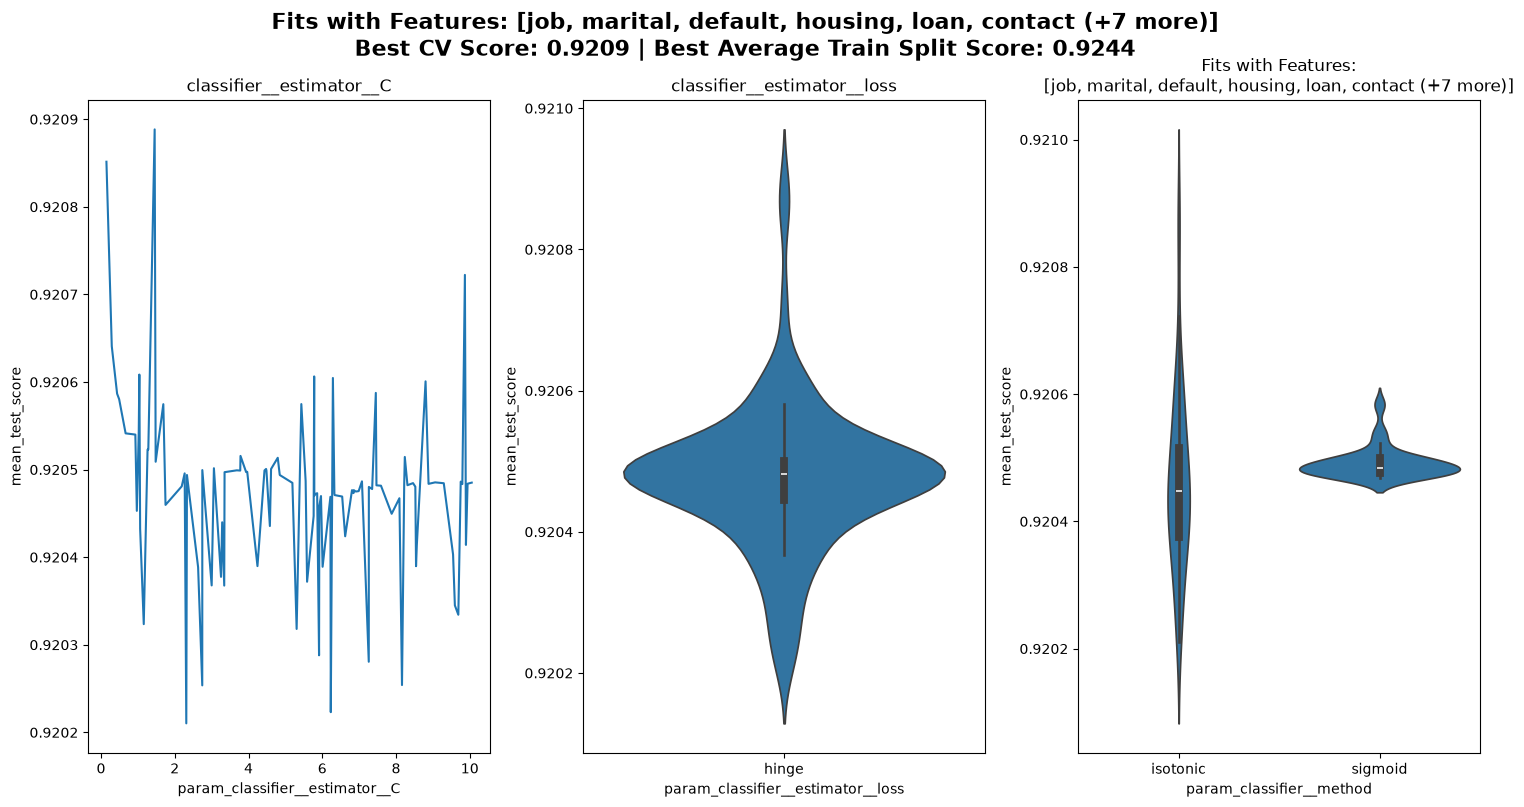



Feature Permutation Importance
______________________
duration: 0.313 +/- 0.008
month: 0.084 +/- 0.005
housing: 0.012 +/- 0.002
day: 0.011 +/- 0.002
campaign: 0.000 +/- 0.001
balance: 0.000 +/- 0.000
contact: 0.000 +/- 0.000
education: 0.000 +/- 0.001
age: 0.000 +/- 0.000
default: -0.000 +/- 0.000
job: -0.000 +/- 0.001
loan: -0.000 +/- 0.000
marital: -0.000 +/- 0.001

______________________



classifier:  CalibratedClassifierCV(cv=5,
                       estimator=LinearSVC(C=np.float64(1.4547406422245024),
                                           loss='hinge', max_iter=10000000,
                                           random_state=0),
                       method='isotonic') 





100%|██████████| 5259/5259 [04:54<00:00, 17.85it/s]
e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:409: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


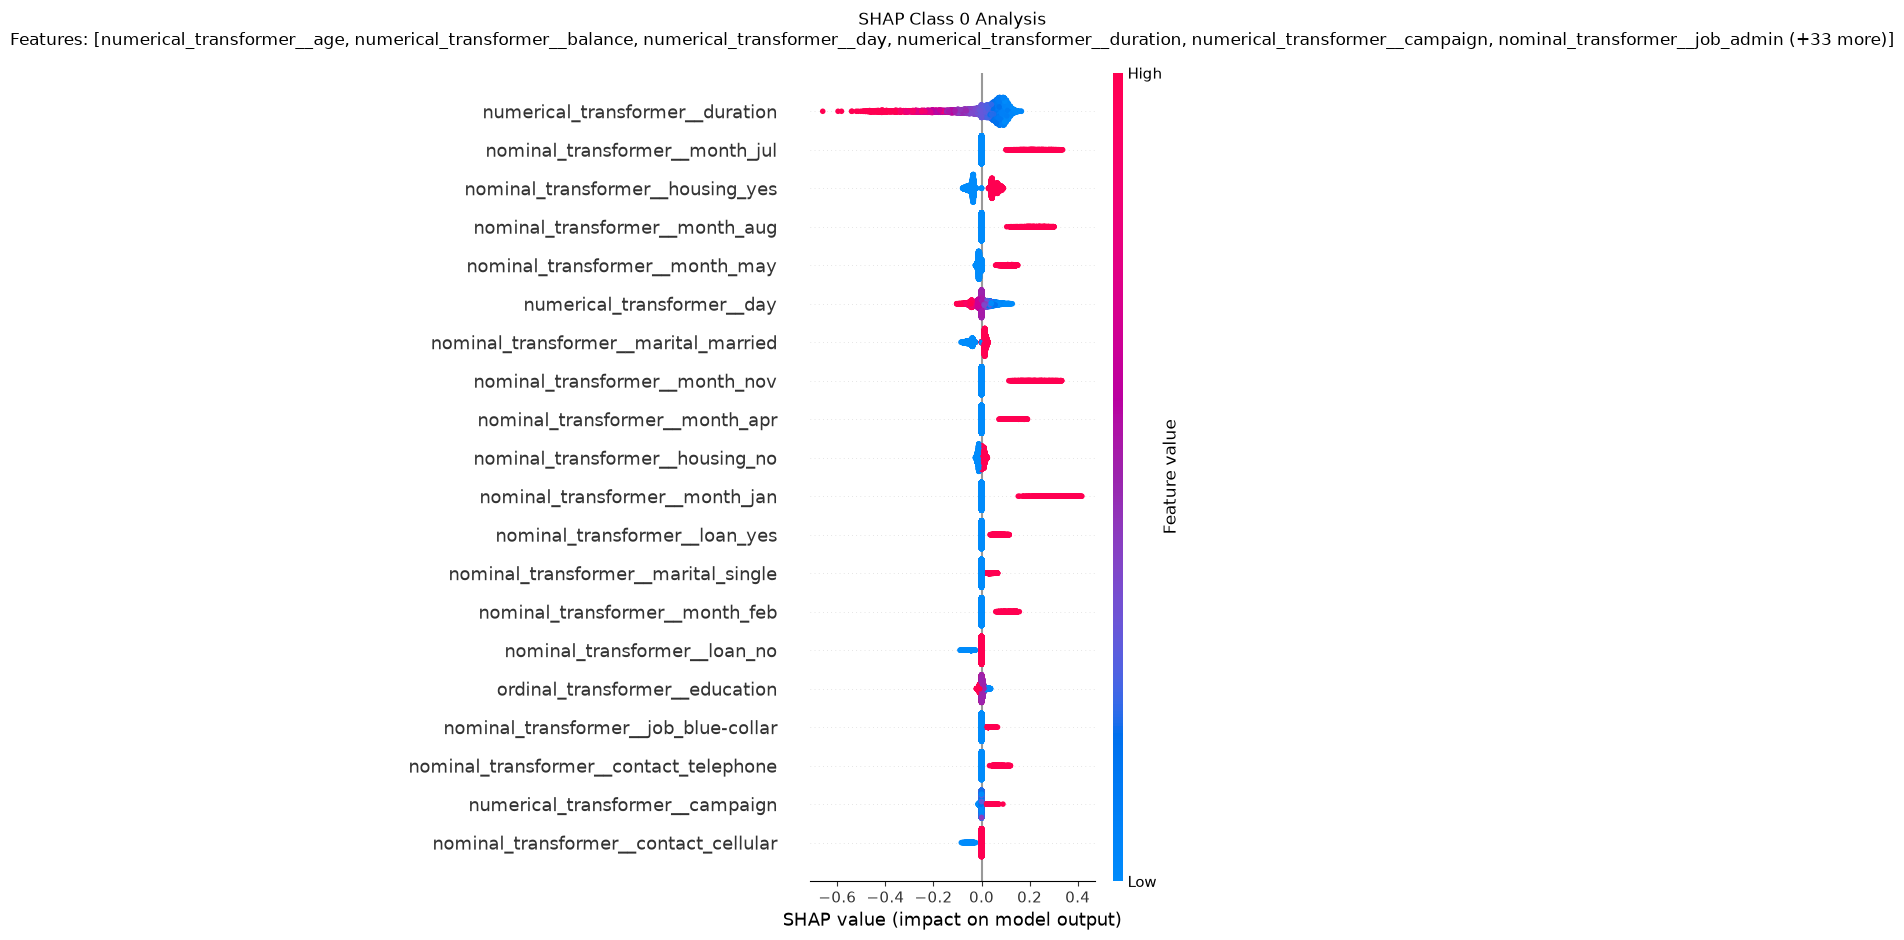

e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:409: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


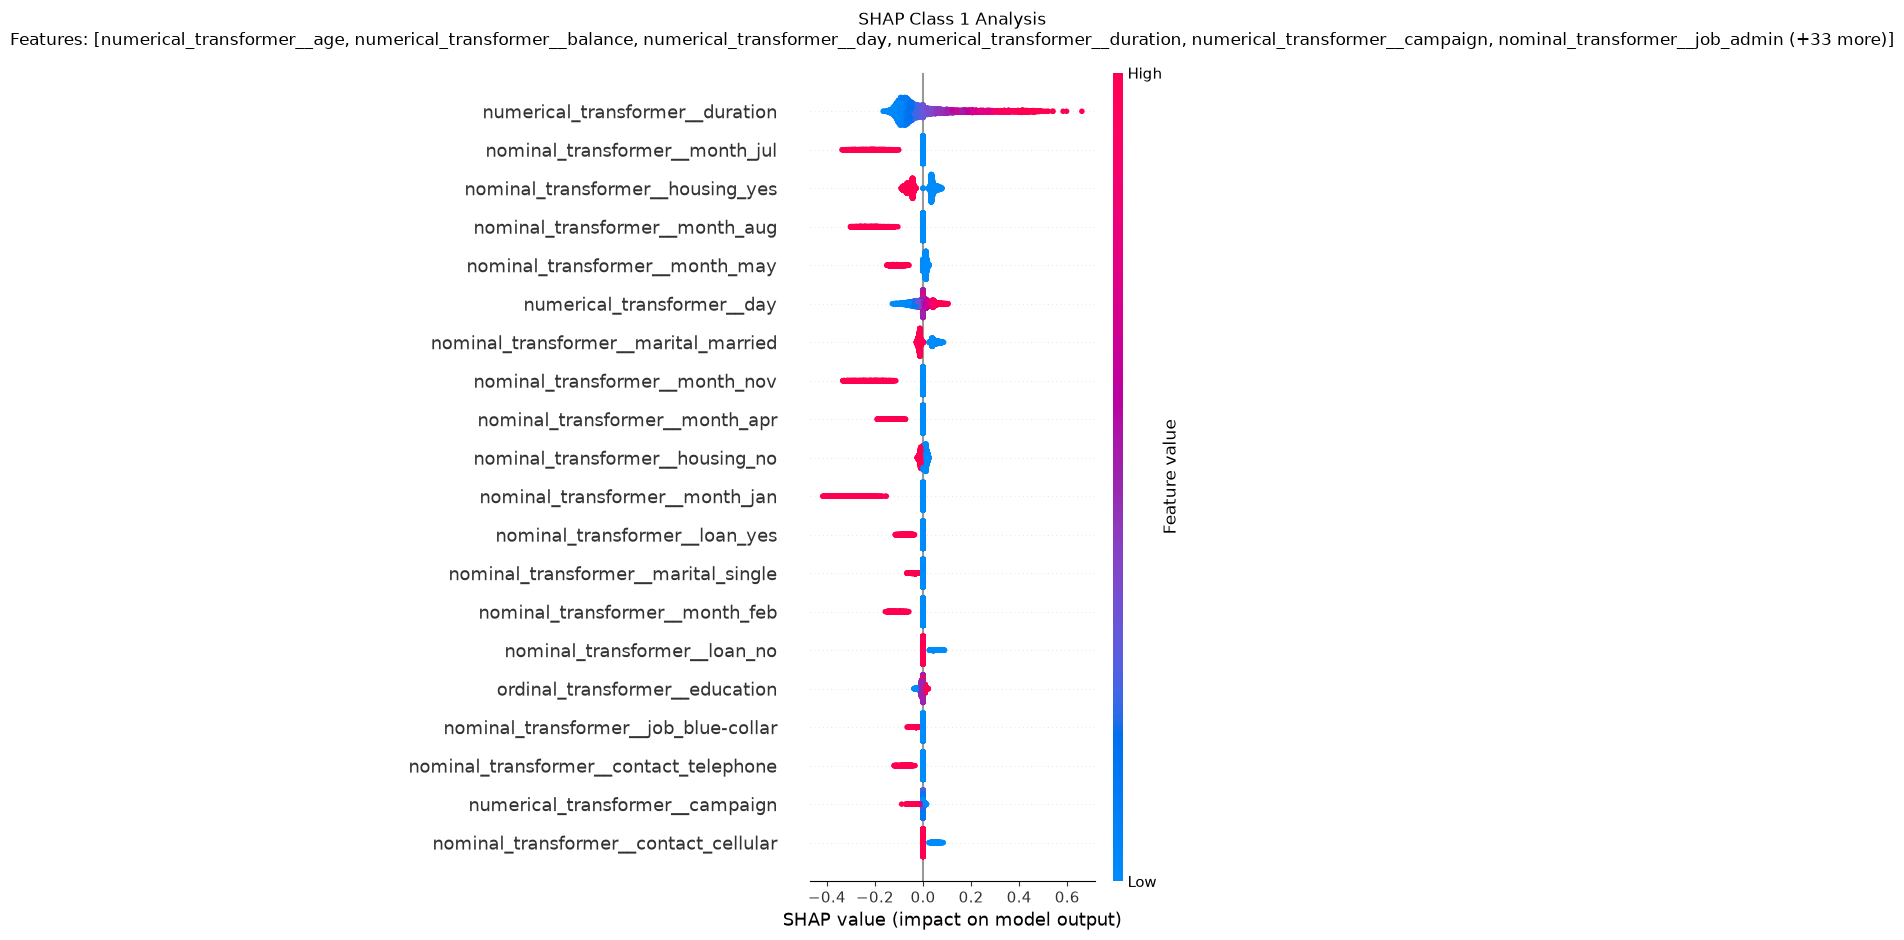

Encountered error: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)
Trying non-numeric method
Encountered error: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)
Trying non-numeric method
Encountered error: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no commo

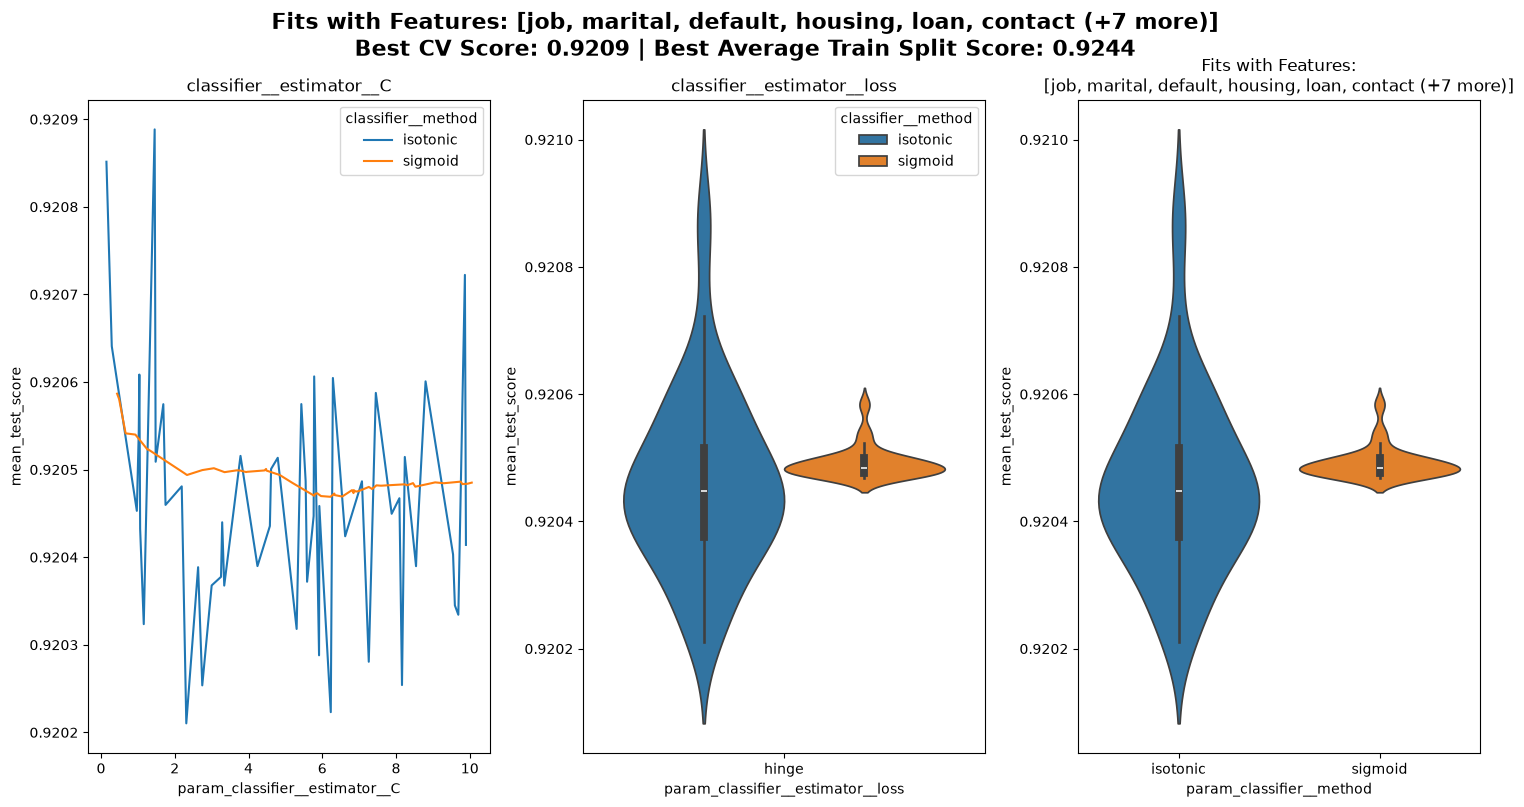

In [3]:
# Define your features
nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact', 'month',]

ordinal_features = ['education',]
education_order = ["primary", "secondary", "tertiary"]

numerical_features = ['age', 'balance','day', 'duration', 'campaign',]

all_features = nominal_features + ordinal_features + numerical_features



# 2. Create the transformers
numerical_transformer = Pipeline(
    steps=[
        ("Numerical", StandardScaler()),  
    ]
)
nominal_transformer = Pipeline(
    steps=[
        ("NominalEncoder", OneHotEncoder()),  
    ]
)
ordinal_transformer = Pipeline(
    steps=[
        ("OrdinalEncoder", OrdinalEncoder(categories=[education_order])), 
        ("OrdinalScaler", StandardScaler()),  
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_transformer",
            numerical_transformer,
            numerical_features,
        ),
        (
            "nominal_transformer",
            nominal_transformer,
            nominal_features,
        ),
        (
            "ordinal_transformer",
            ordinal_transformer,
            ordinal_features,
        ),
    ],
    remainder="passthrough",  # Keeps any other columns untouched
)

base_svc = LinearSVC(max_iter=10000000, random_state=random_state)
calibrated_svc = CalibratedClassifierCV(estimator=base_svc, cv=5)

# 4. Final Pipeline structure
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", calibrated_svc),
    ]
)

parameter_grid = {
    "classifier__estimator__C": uniform(0.1,10),
    "classifier__estimator__loss": ["hinge"],
    "classifier__method": ["sigmoid", "isotonic"],
}


split = get_split_from_file(filename = filename, predictor='y', random_state = random_state)
t = PipelineTuner(pipeline, split=split, featureNames=all_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100, scoring = 'roc_auc')
t.feature_permutation(search.best_params_, scoring = 'roc_auc')
t.shap_analysis(search.best_params_, model_type="kernel")
t.display_parameter_fits(search, parameter_grid, groupby="classifier__method")

In [4]:
t.predict_test_split(t.last_search.best_params_, scoring = ["roc_auc","accuracy"])

{'roc_auc': 0.9214326823829072, 'accuracy': 0.9247005134055905}

In [5]:
t.save_model(filename="../../src/models/saved_models/drop_data_CalibratedClassifierCV_LinearSVC", hyperparams=t.last_search.best_params_, final=True, notes="Trained with ROC_AUC, CV: 0.92.09, {'roc_auc': 0.9214326823829072, 'accuracy': 0.9247005134055905}")